# RQ2 — Which algorithm is most reliable in terms of low overfitting?
**Metric**: `overfitting = change_perc_validate − change_perc_train` (more positive = more overfitting; negative = generalises better than it trains).  
**Algorithms**: FirstImprovement (FI), GeneticProgrammingUniformConcat (GP), RandomSearch, UMDAAlgorithm (UMDA4GI) — all without LLM.  
**Data**: Perf\<Cycles\>, 5-fold CV, budgets {100, 250, 500, 750, 1000}.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

os.makedirs('plots', exist_ok=True)

# READ-ONLY — never write back to results.csv
CSV_PATH = Path('..') / 'results' / 'results.csv'
df_all = pd.read_csv(CSV_PATH)

RQ2_ALGOS = ['FirstImprovement', 'GeneticProgrammingUniformConcat', 'RandomSearch', 'UMDAAlgorithm']

df = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'].isin(RQ2_ALGOS))
].copy()

# Keep only rows without LLM (pandas reads 'None' from CSV as pd.NA)
df = df[df['llm_model'].isna()]

df['pop_size']             = pd.to_numeric(df['pop_size'],  errors='coerce').fillna(-1).astype(int)
df['max_evals']            = pd.to_numeric(df['max_evals'], errors='coerce').astype(int)
df['change_perc_validate'] = pd.to_numeric(df['change_perc_validate'], errors='coerce')
df['change_perc_train']    = pd.to_numeric(df['change_perc_train'],    errors='coerce')
df['Vt']                   = pd.to_numeric(df['Vt'],                   errors='coerce')
df['Vc']                   = pd.to_numeric(df['Vc'],                   errors='coerce')

print(f'Rows: {len(df)}')
print(f'Algorithms: {sorted(df["algorithm"].unique())}')
print(f'Softwares:  {sorted(df["software"].unique())}')
print(f'max_evals:  {sorted(df["max_evals"].unique())}')

FIXED_COLORS = {
    'FirstImprovement':                cm.tab10(0),
    'GeneticProgrammingUniformConcat': cm.tab10(1),
    'RandomSearch':                    cm.tab10(2),
    'UMDAAlgorithm':                   cm.tab10(3),
    'UMDA4GI':                         cm.tab10(3),
    'UMDA+llama':                      cm.tab10(4),
    'UMDA+qwen':                       cm.tab10(5),
    'LLM-llama':                       cm.tab10(6),
    'LLM-qwen':                        cm.tab10(7),
}


Rows: 400
Algorithms: ['FirstImprovement', 'GeneticProgrammingUniformConcat', 'RandomSearch', 'UMDAAlgorithm']
Softwares:  ['minisat_hack', 'pngOptim', 'sat4j', 'weka']
max_evals:  [np.int64(100), np.int64(250), np.int64(500), np.int64(750), np.int64(1000)]


## 0. Data Quality — Runs with no improvement found

Of the 400 runs in the no-LLM dataset (4 algorithms × 4 softwares × 5 folds × 5 budgets), **11 returned no improvement over the original program** (`patch_length = 0`): the algorithm exhausted its evaluation budget without finding a variant that performed better than the reference. This is expected behaviour — magpie keeps the original as the best individual and writes no patch file.

For RQ2 these runs contribute `overfitting = change_perc_validate − change_perc_train = 0 − 0 = 0%` to the aggregated values. Breakdown: **8 Weka runs** (FirstImprovement, various folds and budgets) and **3 OptimPNG runs**.

In [2]:
# Runs where no better variant was found (patch_length == 0)
no_improvement = df[df['patch_length'] == 0][
    ['software', 'algorithm', 'fold', 'max_evals', 'change_perc_train', 'change_perc_validate', 'patch_length']
].sort_values(['software', 'algorithm', 'max_evals', 'fold']).reset_index(drop=True)

print(f'Runs with patch_length == 0: {len(no_improvement)} / {len(df)}')
display(no_improvement)

Runs with patch_length == 0: 0 / 400


,software,algorithm,fold,max_evals,change_perc_train,change_perc_validate,patch_length


In [3]:
group_cols = ['software', 'algorithm', 'pop_size', 'max_evals', 'fitness']

averaged_results = (
    df.groupby(group_cols, as_index=False)
      .agg(
          change_perc_train   =('change_perc_train',    'median'),
          change_perc_validate=('change_perc_validate', 'median'),
          Vt                  =('Vt',                   'mean'),
          Vc                  =('Vc',                   'mean'),
          n_folds             =('fold',                 'count'),
      )
)

# Sanity check
bad = averaged_results[averaged_results['n_folds'] != 5]
if bad.empty:
    print('OK — all groups have exactly 5 folds')
else:
    print(f'WARNING — {len(bad)} groups do not have 5 folds:')
    display(bad)

# Compute overfitting: positive = overfits, negative = generalises better than trains
averaged_results['overfit'] = averaged_results['change_perc_validate'] - averaged_results['change_perc_train']

print(f'Aggregated rows: {len(averaged_results)}')

OK — all groups have exactly 5 folds
Aggregated rows: 80


## 1. Overfitting curves — (validate − train) vs max_evals (per software)

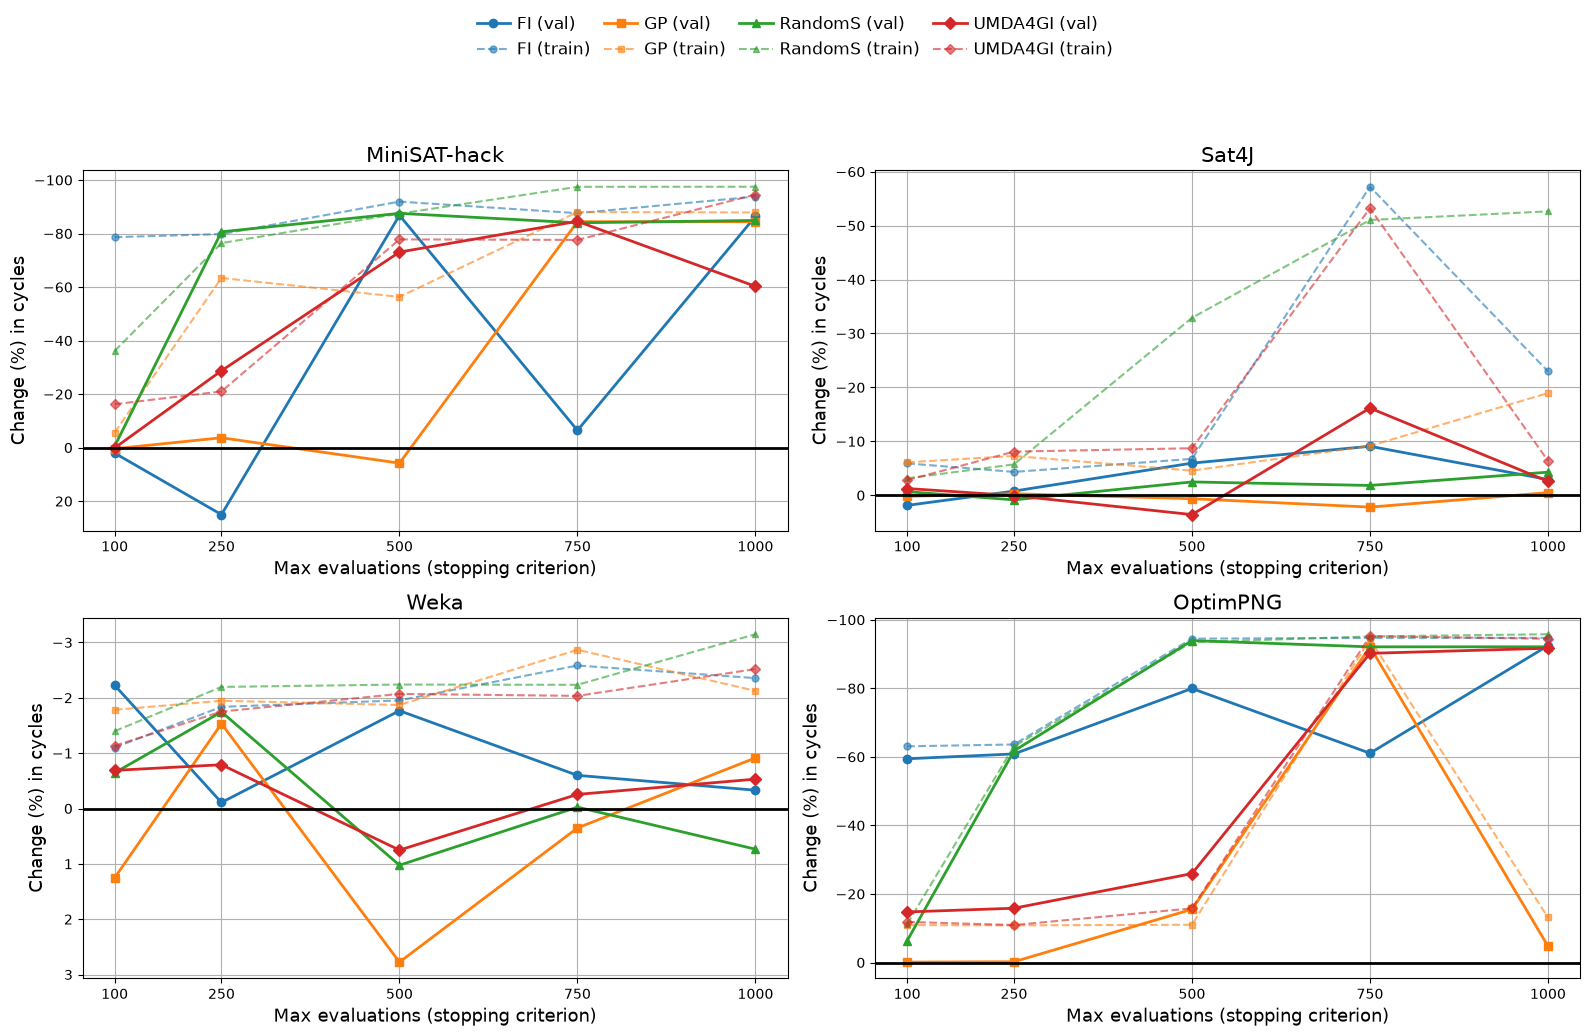

In [4]:
legend_name_map = {
    'FirstImprovement':                'FI',
    'GeneticProgrammingUniformConcat': 'GP',
    'RandomSearch':                    'RandomS',
    'UMDAAlgorithm':                   'UMDA4GI',
}
software_display_map = {
    'minisat_hack': 'MiniSAT-hack',
    'sat4j':        'Sat4J',
    'weka':         'Weka',
    'pngOptim':     'OptimPNG',
}
desired_order = ['minisat_hack', 'sat4j', 'weka', 'pngOptim']

markers = ['o', 's', '^', 'D']

algorithms_all = list(averaged_results['algorithm'].unique())
color_map = {alg: FIXED_COLORS.get(alg, cm.tab10(i % 10)) for i, alg in enumerate(algorithms_all)}

softwares = [sw for sw in desired_order if sw in averaged_results['software'].values]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, software in zip(axes, softwares):
    sw_data = averaged_results[averaged_results['software'] == software]
    for i, alg in enumerate(algorithms_all):
        alg_data = sw_data[sw_data['algorithm'] == alg].sort_values('max_evals')
        if alg_data.empty:
            continue
        label = legend_name_map.get(alg, alg)
        col = color_map[alg]
        mk = markers[i % len(markers)]
        # Validation: solid line
        ax.plot(
            alg_data['max_evals'], alg_data['change_perc_validate'],
            linestyle='-', marker=mk, color=col, linewidth=2, markersize=6,
            label=f'{label} (validate)',
        )
        # Train: dashed line
        ax.plot(
            alg_data['max_evals'], alg_data['change_perc_train'],
            linestyle='--', marker=mk, color=col, linewidth=1.5, markersize=5,
            alpha=0.6, label=f'{label} (train)',
        )
    ax.set_title(software_display_map.get(software, software), fontsize=15)
    ax.set_xlabel('Max evaluations (stopping criterion)', fontsize=13)
    ax.set_ylabel('Change (%) in cycles', fontsize=13)
    ax.invert_yaxis()
    ax.set_xticks(sorted(sw_data['max_evals'].unique()))
    ax.axhline(y=0, color='k', linestyle='-', linewidth=2)
    ax.grid(True)

for i in range(len(softwares), len(axes)):
    axes[i].axis('off')

# Build compact legend: one solid + one dashed entry per algorithm
import matplotlib.lines as mlines
legend_handles = []
for i, alg in enumerate(algorithms_all):
    col = color_map[alg]
    mk = markers[i % len(markers)]
    label = legend_name_map.get(alg, alg)
    legend_handles.append(mlines.Line2D([], [], color=col, linestyle='-', marker=mk,
                                         linewidth=2, markersize=6, label=f'{label} (val)'))
    legend_handles.append(mlines.Line2D([], [], color=col, linestyle='--', marker=mk,
                                         linewidth=1.5, markersize=5, alpha=0.6, label=f'{label} (train)'))

fig.legend(handles=legend_handles,
           loc='upper center', bbox_to_anchor=(0.5, 1.04),
           ncol=len(algorithms_all), fontsize='large', frameon=False,
           columnspacing=0.8, handletextpad=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig('plots/RQ2_overfitting_2x2.svg', format='svg', bbox_inches='tight')
plt.show()

## 2. Overfitting tables — mean (validate − train) per software × max_evals

In [5]:
grp_ov = averaged_results.groupby(['software', 'algorithm', 'max_evals'], as_index=False)['overfit'].mean()

for alg in sorted(grp_ov['algorithm'].unique()):
    pivot = (
        grp_ov[grp_ov['algorithm'] == alg]
        .pivot(index='max_evals', columns='software', values='overfit')
        .sort_index()
    )
    pivot.columns = [software_display_map.get(c, c) for c in pivot.columns]
    display(f'Overfit (val − train) for {legend_name_map.get(alg, alg)}:')
    display(pivot.round(4))

'Overfit (val − train) for FI:'

,MiniSAT-hack,OptimPNG,Sat4J,Weka
max_evals,,,,
100,80.696,3.635,7.789,-1.125
250,104.835,2.762,3.558,1.728
500,5.112,14.534,0.787,0.186
750,81.161,33.660,48.129,1.985
1000,7.418,2.287,20.051,2.025


'Overfit (val − train) for GP:'

,MiniSAT-hack,OptimPNG,Sat4J,Weka
max_evals,,,,
100,6.059,10.787,6.298,3.036
250,59.723,10.622,7.011,0.414
500,62.114,-4.499,5.202,4.645
750,3.608,2.164,11.344,3.219
1000,3.472,8.348,18.457,1.211


'Overfit (val − train) for RandomS:'

,MiniSAT-hack,OptimPNG,Sat4J,Weka
max_evals,,,,
100,35.585,4.865,2.476,0.751
250,-4.200,1.360,6.584,0.451
500,-0.108,-0.493,30.432,3.264
750,13.453,3.038,49.232,2.210
1000,12.594,3.664,48.364,3.884


'Overfit (val − train) for UMDA4GI:'

,MiniSAT-hack,OptimPNG,Sat4J,Weka
max_evals,,,,
100,16.348,-2.901,1.552,0.445
250,-7.737,-4.899,8.156,0.961
500,4.740,-10.136,12.308,2.822
750,-6.947,5.006,37.063,1.780
1000,34.292,2.764,3.818,1.989


## 3. Ranking — algorithms by mean overfitting per software (1 = least overfitting)

In [6]:
overall_avg_ov = grp_ov.groupby(['software', 'algorithm'], as_index=False)['overfit'].mean()
overall_avg_ov['rank'] = overall_avg_ov.groupby('software')['overfit'].rank(method='min')

rank_alg_ov = overall_avg_ov.pivot(index='algorithm', columns='software', values='rank').sort_index()
rank_alg_ov.index   = [legend_name_map.get(i, i) for i in rank_alg_ov.index]
rank_alg_ov.columns = [software_display_map.get(c, c) for c in rank_alg_ov.columns]
rank_alg_ov['Sum'] = rank_alg_ov.sum(axis=1)
rank_alg_ov['Worst'] = rank_alg_ov.drop(columns='Sum').max(axis=1)
rank_alg_ov['Top2'] = (rank_alg_ov.drop(columns=['Sum', 'Worst']) <= 2).sum(axis=1)
rank_alg_ov = rank_alg_ov.sort_values(['Sum', 'Worst', 'Top2'], ascending=[True, True, False])

display('Algorithm ranking by mean overfitting per software (1 = least overfitting):')
display('Tiebreak: Sum → Worst rank (lower better) → Top-2 count (higher better)')
display(rank_alg_ov)

'Algorithm ranking by mean overfitting per software (1 = least overfitting):'

'Tiebreak: Sum → Worst rank (lower better) → Top-2 count (higher better)'

,MiniSAT-hack,OptimPNG,Sat4J,Weka,Sum,Worst,Top2
UMDA4GI,1.0,1.0,2.0,2.0,6.0,2.0,4
RandomS,2.0,2.0,4.0,3.0,11.0,4.0,2
GP,3.0,3.0,1.0,4.0,11.0,4.0,1
FI,4.0,4.0,3.0,1.0,12.0,4.0,1


## 4. Ranking — max_evals by mean overfitting per algorithm (1 = least overfitting)

In [7]:
avg_budget_ov = grp_ov.groupby(['algorithm', 'max_evals'], as_index=False)['overfit'].mean()
avg_budget_ov['rank'] = avg_budget_ov.groupby('algorithm')['overfit'].rank(method='min')

rank_budget_ov = avg_budget_ov.pivot(index='max_evals', columns='algorithm', values='rank').sort_index()
rank_budget_ov.columns = [legend_name_map.get(c, c) for c in rank_budget_ov.columns]

display('max_evals ranking by mean overfitting per algorithm (1 = least overfitting):')
display(rank_budget_ov)

'max_evals ranking by mean overfitting per algorithm (1 = least overfitting):'

,FI,GP,RandomS,UMDA4GI
max_evals,,,,
100,3.0,2.0,3.0,3.0
250,4.0,5.0,1.0,1.0
500,1.0,4.0,2.0,2.0
750,5.0,1.0,4.0,4.0
1000,2.0,3.0,5.0,5.0


## RQ2 — Conclusions

### Direct answer

**UMDA4GI clearly shows the lowest overfitting** (Sum=6, 1st in MiniSAT-hack and OptimPNG, 2nd in Sat4J and Weka). It never ranks worse than 2nd in any software, and is the only algorithm to show **negative overfitting** (generalises better than it trains) systematically in OptimPNG.

### Global ranking (sum of ranks per software, 1 = least overfitting)

**Tiebreaker: when two algorithms have the same Sum, ties are broken first by the worst individual rank (lower = more robust); if still tied, by the number of softwares in which they reach rank ≤ 2 (higher = more consistent).**

| Algorithm | MiniSAT-hack | OptimPNG | Sat4J | Weka | **Sum** | Worst | Top-2 |
|-----------|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **UMDA4GI** | **1** | **1** | 2 | 2 | **6** | 2 | **4** |
| RandomS | 2 | 2 | 4 | 3 | 11 | 4 | 2 |
| GP | 3 | 3 | **1** | 4 | 11 | 4 | 1 |
| FI | 4 | 4 | 3 | **1** | 12 | 4 | 1 |

### Findings per software

**MiniSAT-hack** — the only software with substantial overfitting:
- UMDA4GI (rank 1): most balanced. Negative overfitting at budget=250 (−7.7%) and 750 (−6.9%), indicating generalisation. Overfitting grows at extreme budgets (+16.3% at 100, +34.3% at 1000).
- RandomSearch (rank 2): moderate, with negative overfitting at 250 (−4.2%) and near-zero at 500. Grows at high budgets.
- GP (rank 3): high and sustained overfitting at low-to-medium budgets (6%–62%), dropping at high budgets (3.5%).
- FI (rank 4): **worst overfitting**, with extreme peaks (80.7% at 100, 104.8% at 250, 81.2% at 750). Highly variable.

**OptimPNG** — UMDA4GI generalises better than it trains:
- UMDA4GI (rank 1): **negative overfitting at low-to-medium budgets** (−2.9% at 100, −4.9% at 250, −10.1% at 500). UMDA patches generalise well on this software.
- RandomSearch (rank 2): low positive overfitting (1%–10%).
- GP (rank 3): moderate and consistent overfitting (2%–11%).
- FI (rank 4): variable, with a peak at 750 (+33.7%).

**Sat4J** — moderate overfitting for all algorithms:
- GP wins (rank 1): low and stable overfitting (5%–18%).
- UMDA4GI (rank 2): variable — low at small budgets (1.6%–8.2%) but peaks at 750 (+37%).
- FI (rank 3) and RandomSearch (rank 4): both show overfitting spikes at 750 (48%–49%).

**Weka** — minimal overfitting:
- FI wins (rank 1): lowest overfitting, even negative at 100 (−1.1%).
- UMDA4GI (rank 2): very low (0.4%–2.8%).
- Differences are negligible in practice (all <5%).

### Effect of budget on overfitting

In MiniSAT-hack, UMDA4GI shows a notable pattern: **negative overfitting at medium budgets** (250, 750) and positive at extremes (100, 1000). This suggests that at medium budgets the UMDA distribution captures structural properties of the code that generalise, but at very high budgets it begins to overfit the training set. FI and GP show no such pattern — their overfitting is high and irregular.

In Sat4J, all algorithms show an overfitting spike at 750 evaluations, suggesting a feature of the search landscape at that budget range.

### Implications for the paper

- **UMDA4GI combines good improvement (RQ1, rank 2) with the lowest overfitting (RQ2, rank 1)**, making it the most balanced algorithm overall.
- The **negative overfitting of UMDA4GI** in OptimPNG and MiniSAT-hack is scientifically interesting: probabilistic modelling of the search space may capture structural properties of the code that generalise beyond the training set.
- **FI is the best at improvement (RQ1) but the worst at overfitting (RQ2)** — its aggressive patches are train-specific. There is a clear improvement vs. generalisation trade-off.
- The **overfitting spike in Sat4J at budget=750** for FI/RandomSearch (48%–49%) warrants further investigation.

### Limitations

- Aggregation by **median**: robust to atypical folds and to the 11 runs with no improvement found (see Section 0), but may hide fold-level variability.
- Overfitting in Weka is so small that the ranking there carries little practical significance.